In [1]:
import numpy as np
import pylab as plt
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

(35.0, 50.0)

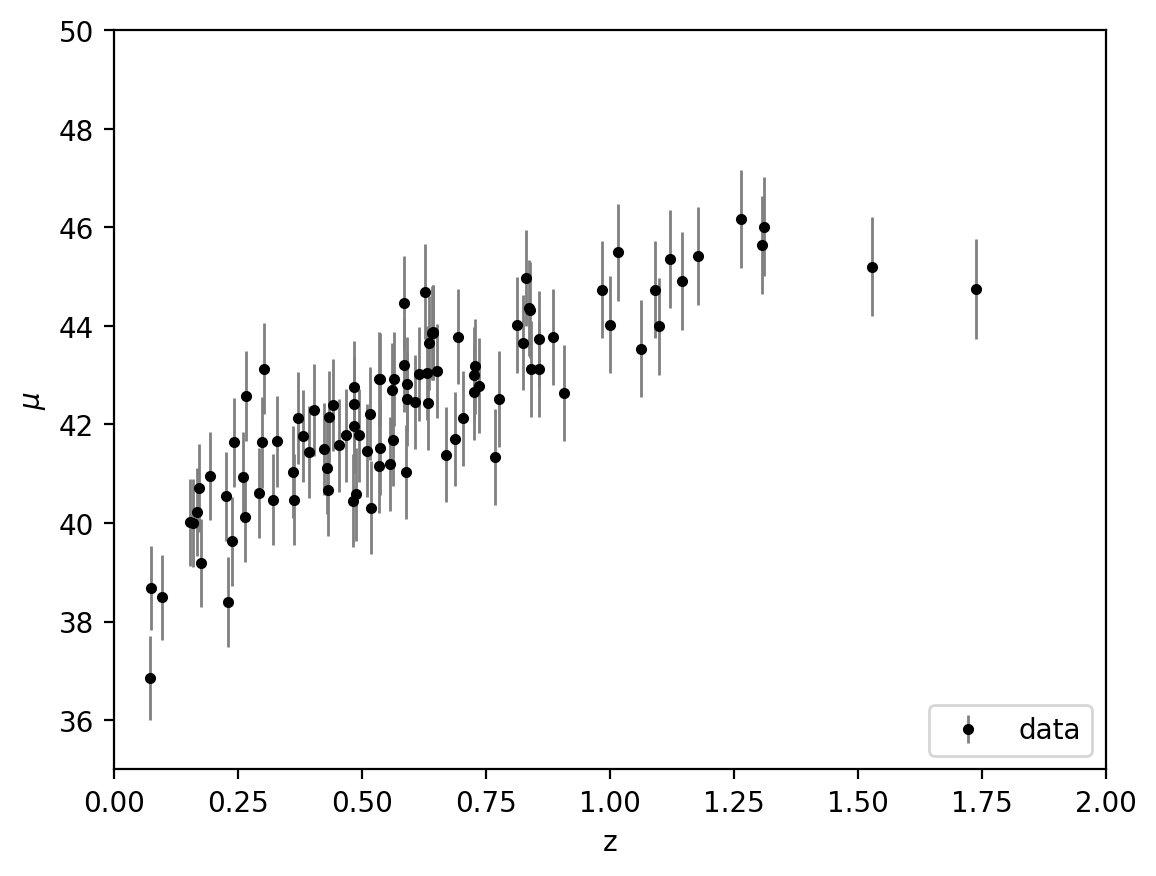

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

## Fitting with Gaussian Process Regressor

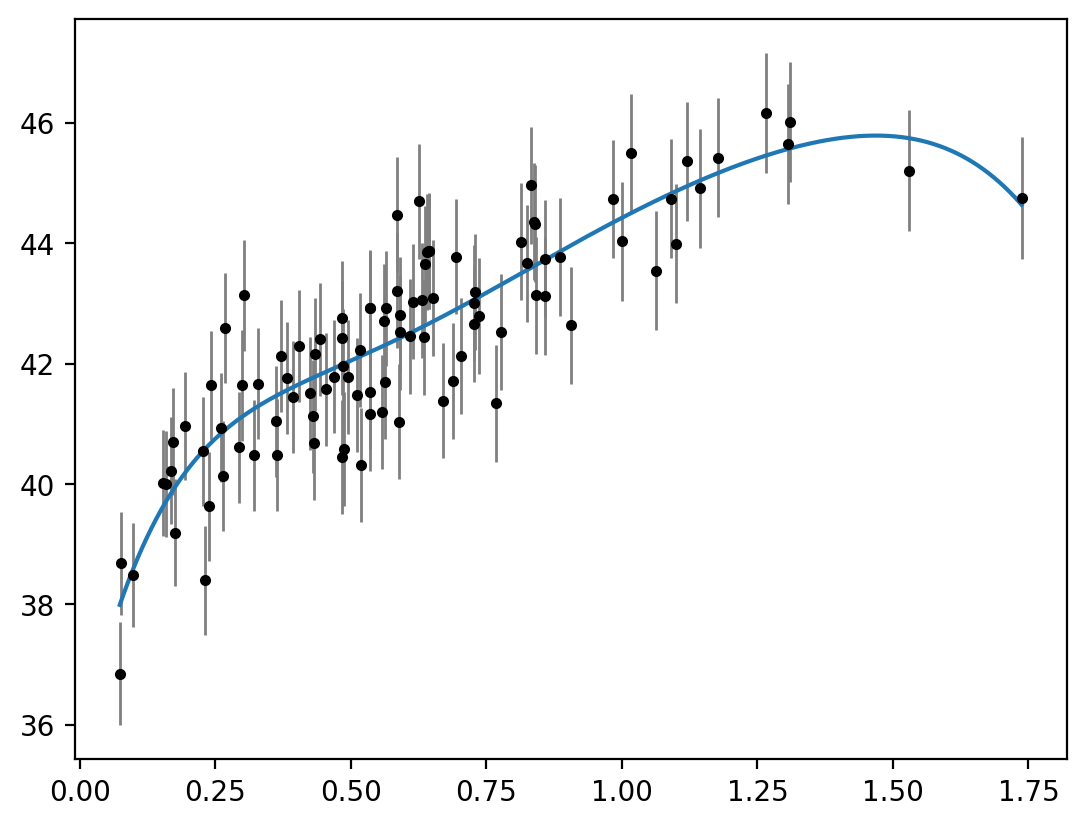

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels

#defining the kernel
kernel1 = kernels.RBF(1/0.5, (1/0.5, 1/0.5))


#fitting with GPR
gp1 = GaussianProcessRegressor(kernel=kernel1, random_state=0, normalize_y=True,optimizer=None)
gp1.fit(z_sample.reshape(-1,1),mu_sample)

X_model = np.linspace(min(z_sample),max(z_sample), 1000)
Y_model = gp1.predict(X_model.reshape(-1,1))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X_model , Y_model)

### Cycling on lenght scale of kernel to see how the plot changes

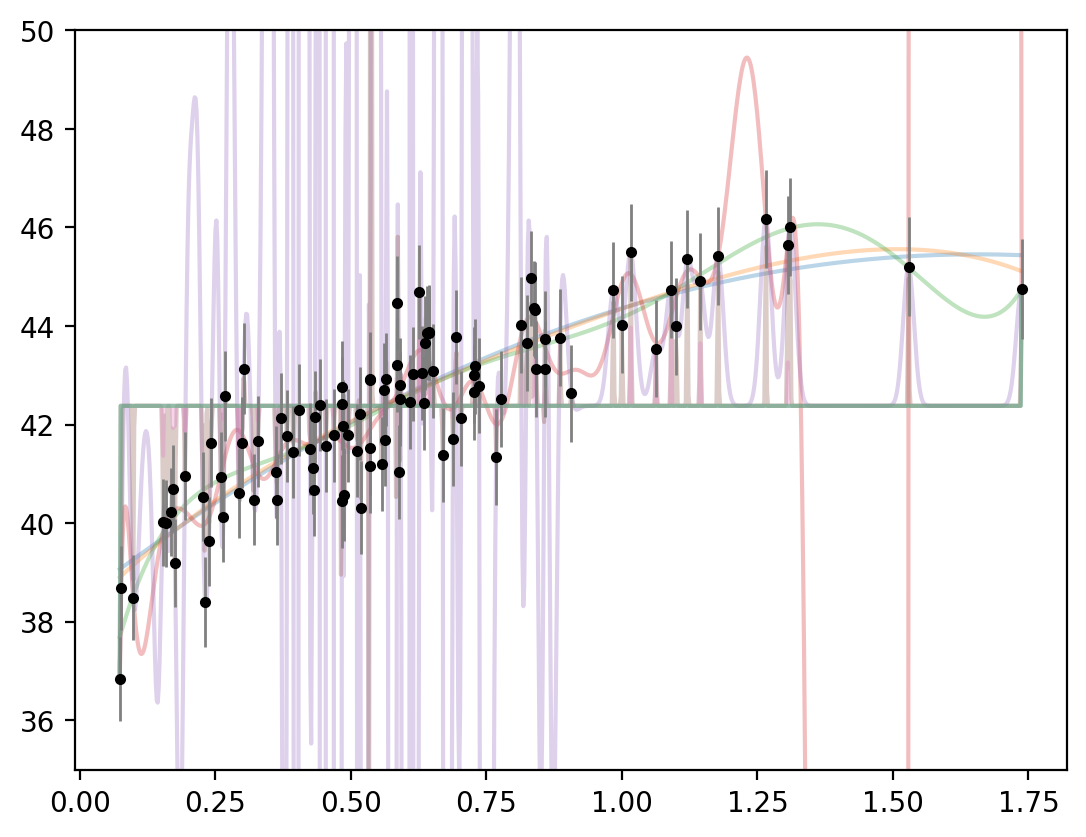

In [4]:
for i in range (10):
    #defining the kernel
    kernel2 = kernels.RBF(100 * 10**(-i), (0.01, 10.0))

    #fitting with GPR
    gp2 = GaussianProcessRegressor(kernel=kernel2, random_state=0, normalize_y=True,optimizer=None)
    gp2.fit(z_sample.reshape(-1,1),mu_sample)

    X_model = np.linspace(min(z_sample),max(z_sample), 1000)
    Y_model = gp2.predict(X_model.reshape(-1,1))
    
    plt.plot(X_model , Y_model, alpha = 0.3)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.ylim(35 , 50)
plt.show()

#### trying to set the scale using the scale of the distance between two point on x

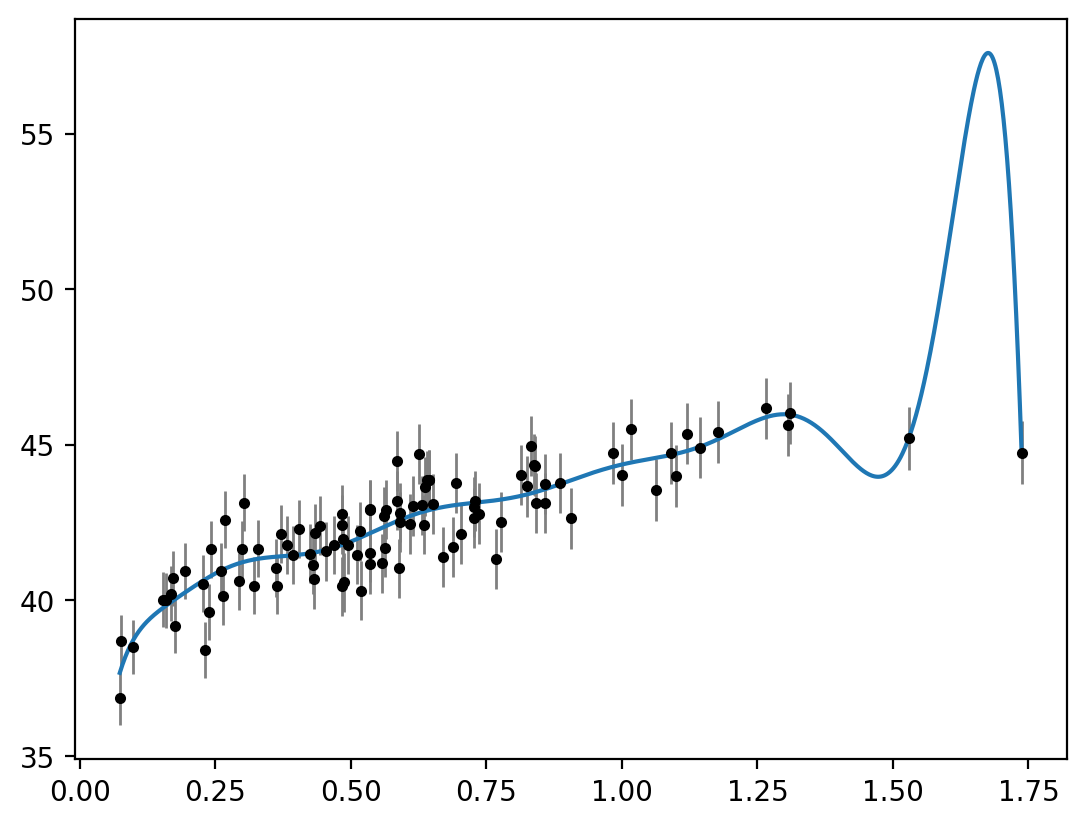

In [5]:
#defining the kernel
kernel_scaled = kernels.RBF(0.5, (1/0.5, 1/0.5))


#fitting with GPR
gp1 = GaussianProcessRegressor(kernel=kernel_scaled, random_state=0, normalize_y=True,optimizer=None)
gp1.fit(z_sample.reshape(-1,1),mu_sample)

X_model = np.linspace(min(z_sample),max(z_sample), 1000)
Y_model = gp1.predict(X_model.reshape(-1,1))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X_model , Y_model)

(seems to overfit)

maybe a smarter way is computing the best scale with cross validation
 (we can see that the optimal range should be from 0.5 to 5):



(0.0, 10.0)

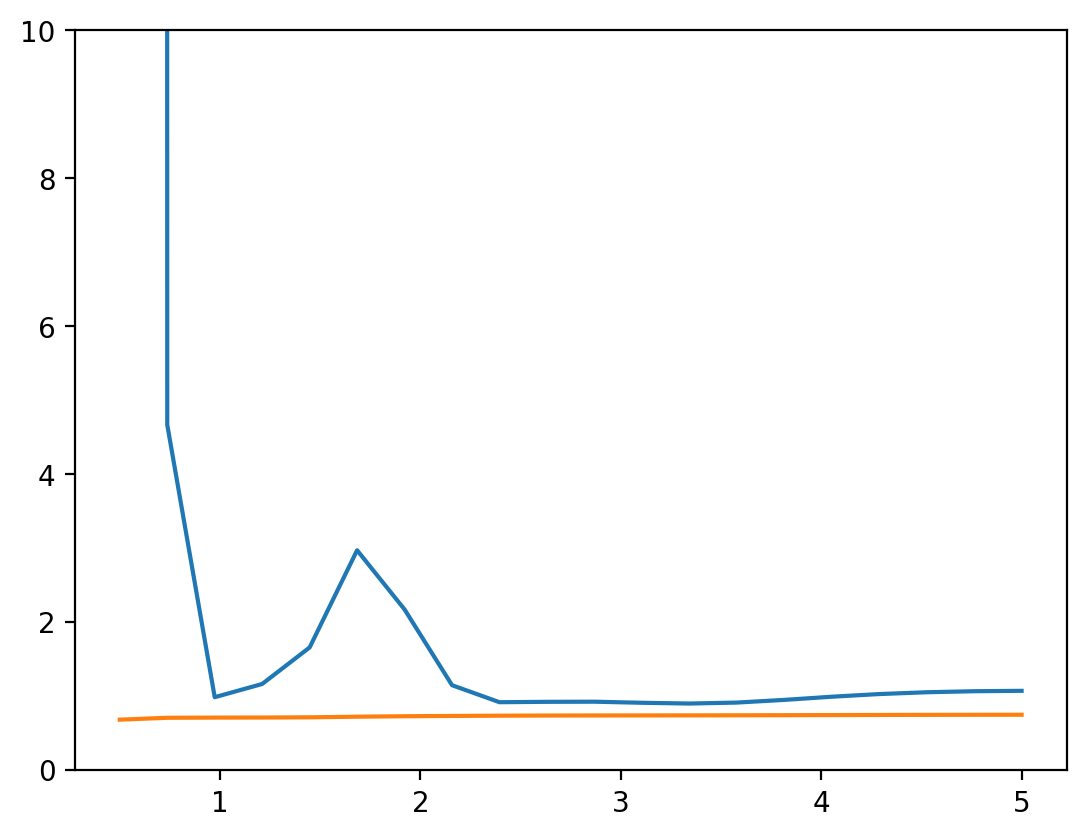

In [15]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

test_score = np.array([])
train_score = np.array([])

size = 20
scale = np.linspace(0.5 , 5, size)
for i in range (size):
    #defining the kernel
    kernel_optimal = kernels.RBF(scale[i], (0, 10))

    #fitting with GPR
    gpr = GaussianProcessRegressor(kernel=kernel_optimal, random_state=0, normalize_y=True,optimizer=None)
    gpr.fit(z_sample.reshape(-1,1),mu_sample)
    
    #cross-validate
    k_folds = KFold(n_splits = 5)
    cv_results =  cross_validate(gpr, z_sample.reshape(-1,1), mu_sample, cv = k_folds, scoring='neg_mean_squared_error', return_train_score=True)
    test_score = np.append(test_score,- np.mean(cv_results['test_score']))
    train_score = np.append(train_score,- np.mean(cv_results['train_score']))

plt.plot(scale, test_score)
plt.plot(scale, train_score)
plt.ylim(0, 10)

In [16]:
#computing the right index 
correct_index = np.where((test_score - train_score)==min(test_score - train_score))
optimal_scale = test_score[correct_index][0]

fitting with optimal scale

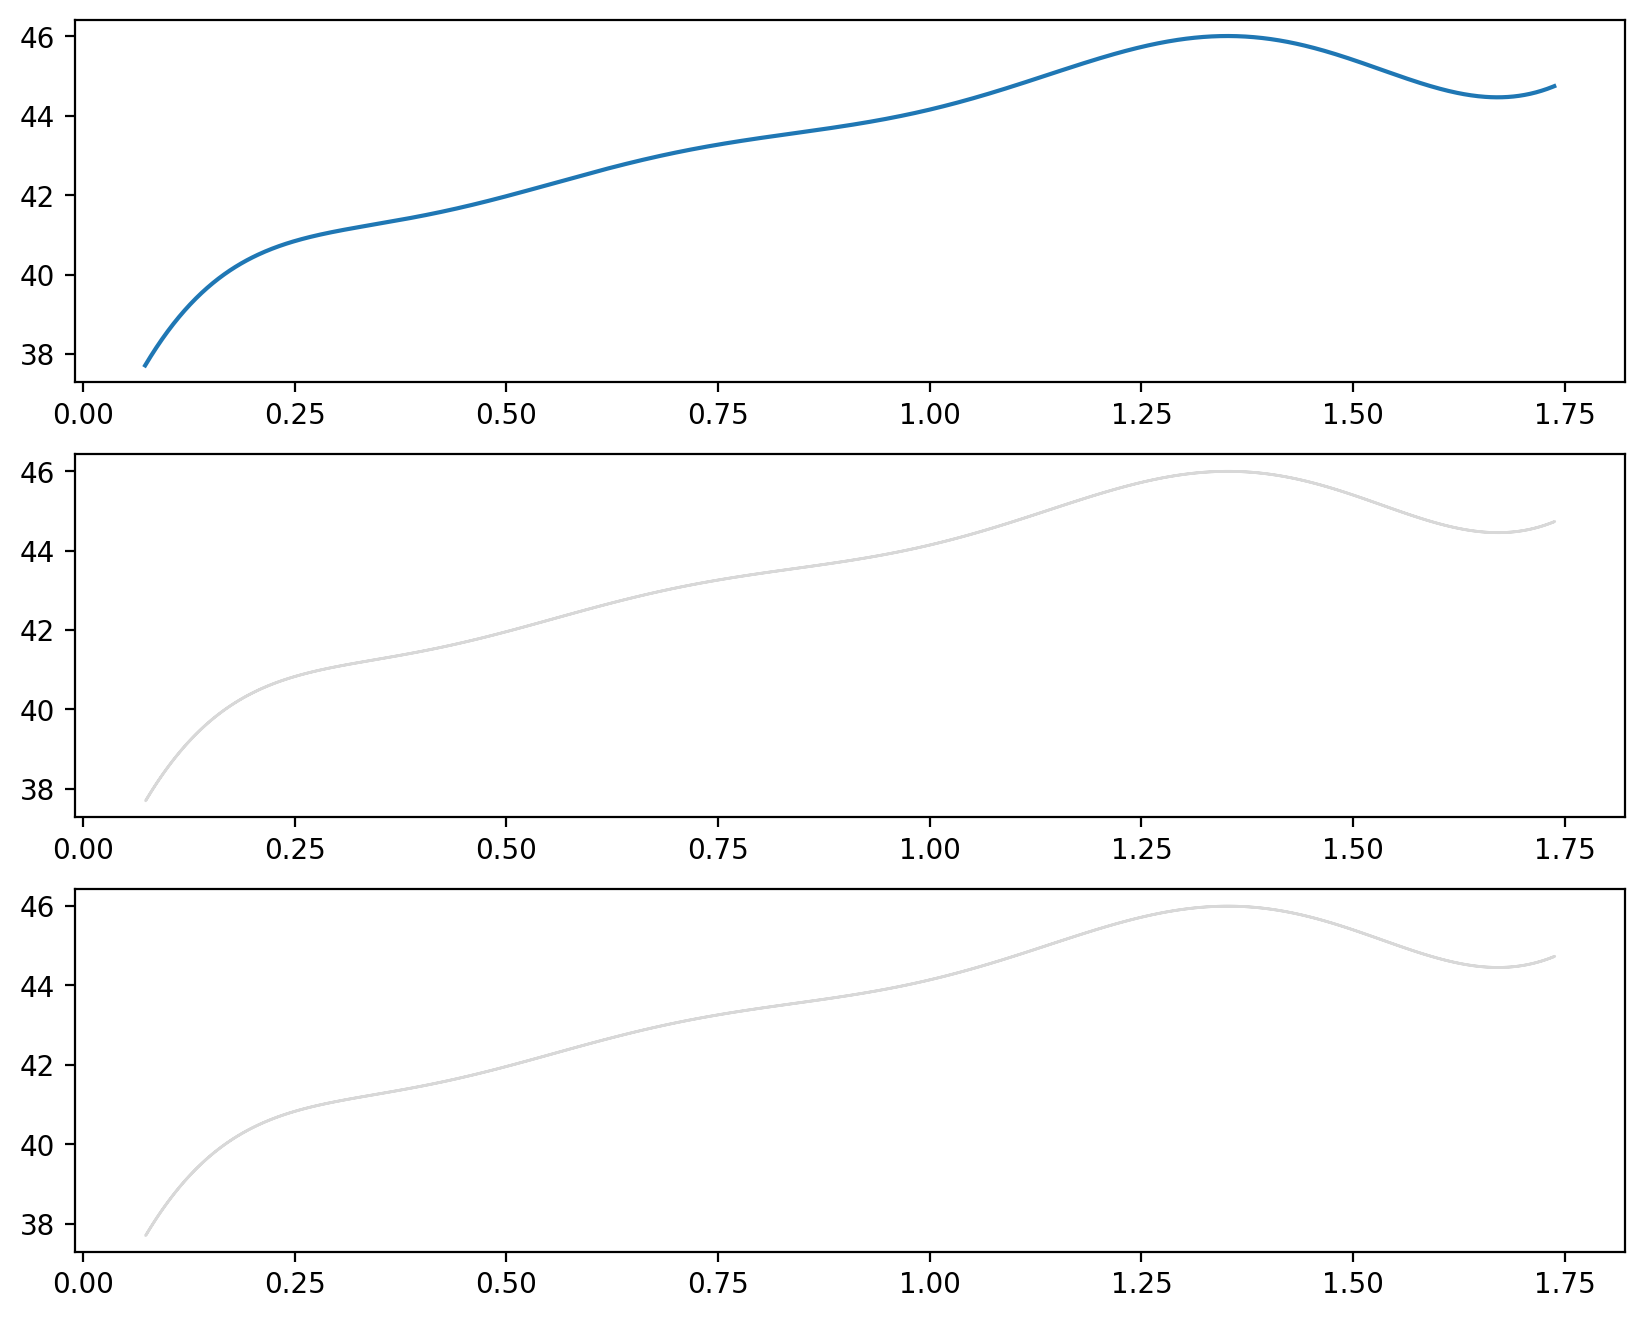

In [17]:
#defining the kernel
kernel = kernels.RBF(optimal_scale, (1/0.5, 1/0.5))


#fitting with GPR
gpr_optimal = GaussianProcessRegressor(kernel=kernel, random_state=0 ,optimizer=None)
gpr_optimal.fit(z_sample.reshape(-1,1),mu_sample)

X_model = np.linspace(min(z_sample),max(z_sample), 1000)
Y_model , Y_err = gpr_optimal.predict(X_model.reshape(-1,1) , return_std = True)

#plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8))
axes[0].plot(X_model , Y_model)
axes[1].fill_between(X_model, Y_model -  Y_err , Y_model +  Y_err, 
                color='gray', alpha=0.3)
axes[2].fill_between(X_model, Y_model -  2*Y_err , Y_model + 2 * Y_err, 
                color='gray', alpha=0.3)
plt.show()

In [9]:
Y_err

array([6.62145803e-06, 6.37647832e-06, 6.14771781e-06, 5.93495685e-06,
       5.73768239e-06, 5.55552581e-06, 5.38790836e-06, 5.23438152e-06,
       5.09435594e-06, 4.96723006e-06, 4.85240476e-06, 4.74900732e-06,
       4.65659499e-06, 4.57420749e-06, 4.50117440e-06, 4.43669407e-06,
       4.38010502e-06, 4.33056305e-06, 4.28739321e-06, 4.24984931e-06,
       4.21729188e-06, 4.18906865e-06, 4.16458798e-06, 4.14329996e-06,
       4.12466188e-06, 4.10807475e-06, 4.09336010e-06, 4.07998039e-06,
       4.06756667e-06, 4.05590885e-06, 4.04457429e-06, 4.03348313e-06,
       4.02222338e-06, 4.01077978e-06, 3.99901194e-06, 3.98654105e-06,
       3.97354209e-06, 3.95988371e-06, 3.94529173e-06, 3.92985463e-06,
       3.91351985e-06, 3.89626187e-06, 3.87805404e-06, 3.85899799e-06,
       3.83890759e-06, 3.81786827e-06, 3.79602512e-06, 3.77315821e-06,
       3.74954494e-06, 3.72500717e-06, 3.69981159e-06, 3.67383891e-06,
       3.64716384e-06, 3.61987821e-06, 3.59209173e-06, 3.56379269e-06,
      

## Trying to visualize the model

###### Playing with parameters in order to get a nice emcee starting point 

In [10]:
import scipy
from scipy.integrate import trapezoid

OmgM = 40 #4000
Omg_Lambd = 1
c = 10**(-9)
H0 = 0.0000001
h = 0.00
def f_scalar(x , OmgM, H0):
    return 1 / np.sqrt(OmgM * (1 + x**3) + Omg_Lambd)
    
f = np.vectorize(f_scalar)

def mu_scalar(x , intgr , OmgM, H0):
    return 5 * np.log(((c / H0)/ 10) * (1 + x) * intgr + h) 

mu = np.vectorize(mu_scalar)

initzialize  4 parameter by making the function pass through 4 points of the data (it is better to take 4 distant ones)

In [11]:
X_model = np.linspace(min(z_sample),max(z_sample), 1000)
X = np.zeros(1000)
intgr = np.zeros(1000)
for i in range (1000):
    X[i] = X_model[i]
    intgr[i] = scipy.integrate.trapezoid(f(X_model, OmgM, H0) , X )

C:\Users\havef\AppData\Local\Temp\ipykernel_47248\4198847238.py:15: RuntimeWarning: invalid value encountered in log
  return 5 * np.log(((c / H0)/ 10) * (1 + x) * intgr + h)


<ErrorbarContainer object of 3 artists>

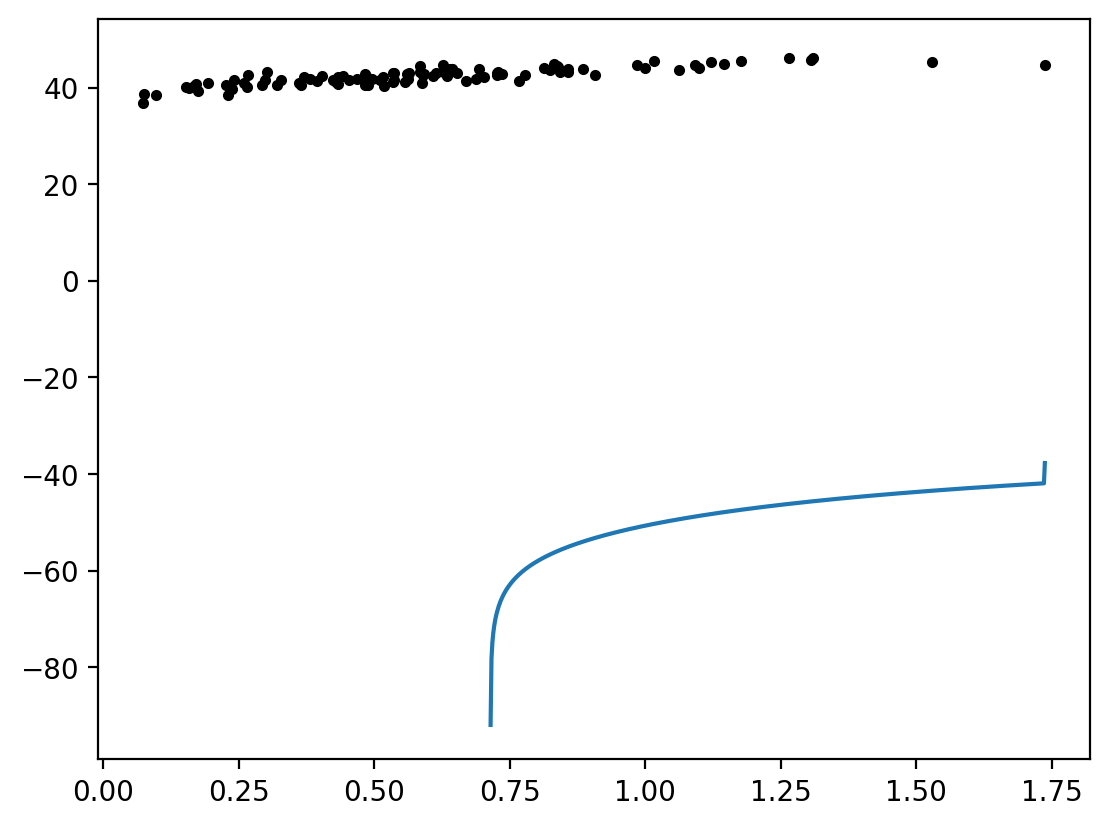

In [12]:
plt.plot(X_model , mu(X_model, intgr , OmgM, H0))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

Creating a more general function that can be implemented in emcee

In [13]:
def f_emcee_scalar(x , OmgM, H0):

    val = np.zeros(np.size(x))
    integral = np.zeros(np.size(x))

    #computing the integral
    for i in x: 
        val[i] = x[i]
        integral =  scipy.integrate.trapezoid(f(x , OmgM, H0) , val)
    return mu(x , integral)

f_emcee = np.vectorize(f_emcee_scalar)

In [14]:
from scipy.optimize import fsolve
def myFunction(z):
    intgr = z[0]
    H0 = z[1]
    F = np.empty(2)
    F[0] = 5 * np.log((c/H0/10) + (1 + z_sample[14]) * intgr) - mu_sample[14]
    F[1] = 5 * np.log((c/H0/10) + (1 + z_sample[86]) * intgr) - mu_sample[14]
zGuess = np.array([1,1])

z = fsolve(myFunction , zGuess)

TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'myFunction'.Shape should be (2,) but it is (1,).

## Fitting with emcee

In [ ]:
import emcee

def log_prior(gamma):
    OmgM, H0 = gamma
    if (0 < OmgM < 50 and np.exp(-5) < H0 < np.exp(5)):
        return 1/100;
    return -np.inf

def log_likelihood(gamma, z_sample , mu_sample):
    OmgM, H0 = gamma
    sigma2 = dmu ** 2
    return -0.5 * np.sum((mu_sample - f(z_sample , gamma[0], gamma[1])) ** 2 / sigma2)

def log_posterior(gamma, z_sample, mu_sample):
    lp = log_prior(gamma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(gamma, z_sample, mu_sample)